In [1]:
import pandas as pd
import numpy as np

# Text preprocessing
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

# Sentiment Analysis
from textblob import TextBlob

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
df = pd.read_csv("blogs.csv")
print(df.head())

                                                Data       Labels
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  alt.atheism
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  alt.atheism
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  alt.atheism


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB
None


In [4]:
print(df['Labels'].value_counts())

Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64


In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)  # tokenize
    tokens = [word for word in tokens if word not in stop_words]  # remove stopwords
    return " ".join(tokens)

In [6]:
nltk.download('punkt_tab', quiet=True)
df['clean_text'] = df['Data'].apply(clean_text)

In [7]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['Labels']

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

# CountVectorizer
count_vec = CountVectorizer(max_features=5000)
X_count = count_vec.fit_transform(df['clean_text'])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [11]:
y_pred = model.predict(X_test)

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8425

Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.50      0.83      0.62        18
           comp.graphics       0.73      0.89      0.80        18
 comp.os.ms-windows.misc       0.91      0.95      0.93        22
comp.sys.ibm.pc.hardware       0.83      0.80      0.82        25
   comp.sys.mac.hardware       0.86      0.90      0.88        21
          comp.windows.x       0.95      0.84      0.89        25
            misc.forsale       1.00      0.78      0.88        18
               rec.autos       0.90      1.00      0.95        18
         rec.motorcycles       1.00      0.94      0.97        16
      rec.sport.baseball       0.84      0.89      0.86        18
        rec.sport.hockey       0.88      1.00      0.94        15
               sci.crypt       0.90      1.00      0.95        19
         sci.electronics       0.67      0.75      0.71        16
                 sci.med       0.

In [13]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [14]:
df['Sentiment'] = df['Data'].apply(get_sentiment)

In [15]:
print(df['Sentiment'].value_counts())

Sentiment
Positive    1543
Negative     457
Name: count, dtype: int64


In [16]:
sentiment_category = pd.crosstab(df['Labels'], df['Sentiment'])
print(sentiment_category)

Sentiment                 Negative  Positive
Labels                                      
alt.atheism                     23        77
comp.graphics                   24        76
comp.os.ms-windows.misc         22        78
comp.sys.ibm.pc.hardware        20        80
comp.sys.mac.hardware           24        76
comp.windows.x                  27        73
misc.forsale                    16        84
rec.autos                       17        83
rec.motorcycles                 26        74
rec.sport.baseball              29        71
rec.sport.hockey                34        66
sci.crypt                       19        81
sci.electronics                 19        81
sci.med                         29        71
sci.space                       27        73
soc.religion.christian          13        87
talk.politics.guns              30        70
talk.politics.mideast           22        78
talk.politics.misc              22        78
talk.religion.misc              14        86


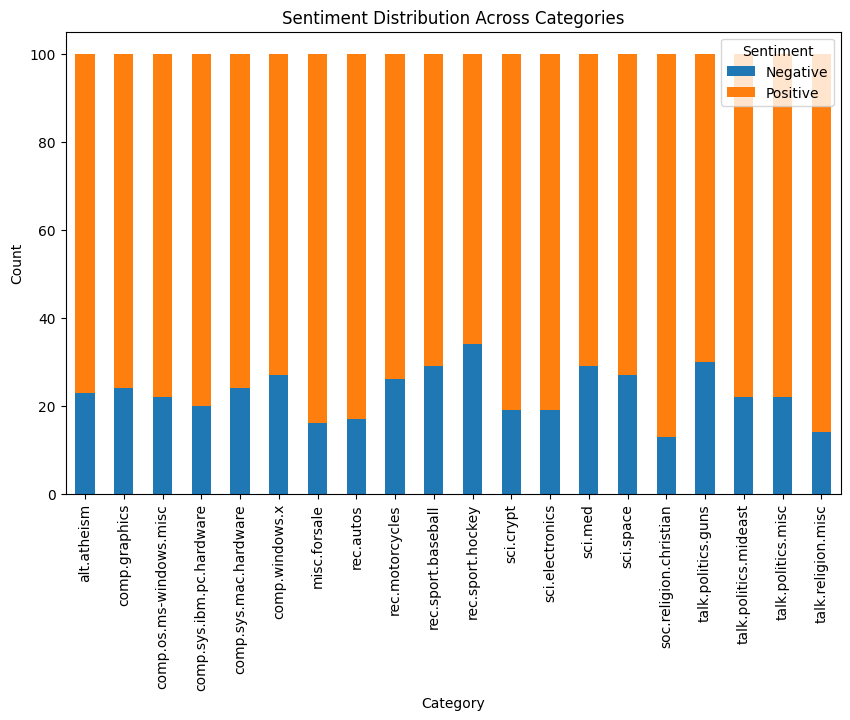

In [17]:
import matplotlib.pyplot as plt

sentiment_category.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Sentiment Distribution Across Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

1.Text Classification

Blog posts ko unke category (Labels) me classify karna
Algorithm: Naive Bayes Algorithm

2.Text Preprocessing

Feature extraction using:
TF-IDF
ya CountVectorizer

3.Sentiment Analysis

Positive
Negative
Neutral

4. Evaluation

Accuracy
Precision
Recall
F1-score


## Conclusion

In this project, we performed text classification on blog posts using the Naive Bayes algorithm. The text data was preprocessed using techniques such as lowercasing, removing punctuation, and stopword removal. Feature extraction was performed using both CountVectorizer and TF-IDF.

The Naive Bayes model was trained and evaluated, and it showed good performance in classifying blog categories. It was observed that TF-IDF provided better accuracy compared to CountVectorizer.

Sentiment analysis was also performed on the blog posts, which helped in understanding the emotional tone of the content. Most of the blog posts were found to have positive sentiment, while some categories showed negative or neutral sentiments.

WordCloud visualization helped in identifying the most frequent words in the dataset.

Overall, the project demonstrates how machine learning and NLP techniques can be used effectively for text classification and sentiment analysis.